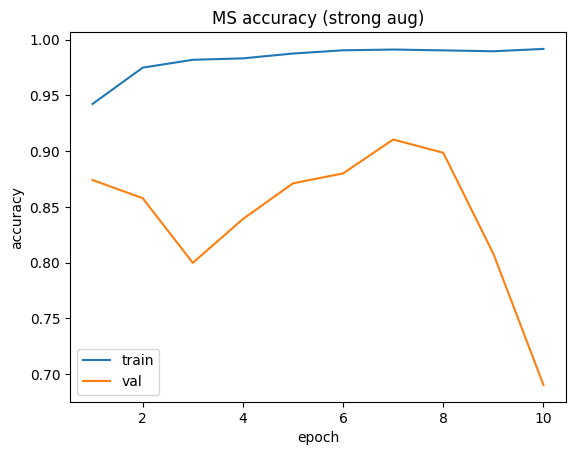

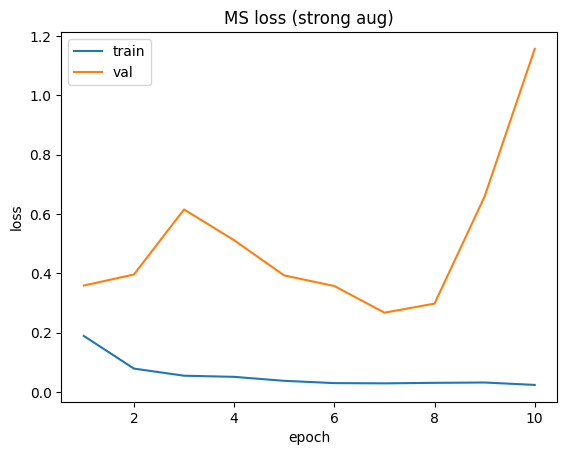

In [1]:
# !pip install --user pandas
# after 7-8 epochs MS model is getting overfitted: 
# Figures "MS accuracy and loss" illustrates the same curves for the multispectral model with strong augmentation. 
# Training accuracy quickly approaches almost 100% and training loss decreases towards zero whereas validation accuracy peaks at about 91% around epoch 7 and drops afterwards. 
# The validation loss reaches its minimum at epoch 7 and then increases sharply. 
# This behaviour is typical for overfitting, and therefore the checkpoint from epoch 7 is selected as the final MS model (..ms_final.pt) 
# which achieves approximately 90.8% accuracy on the held-out test set
# (for comparison RGB below)


import pandas as pd
import matplotlib.pyplot as plt

from config import PROJECT_ROOT

df = pd.read_csv(PROJECT_ROOT / "logs" / "ms_metrics.csv")

# strong augmentation
df_strong_train = df[(df["aug_name"] == "strong") & (df["split"] == "train")]
df_strong_val   = df[(df["aug_name"] == "strong") & (df["split"] == "val")]

# accuracy
plt.figure()
plt.plot(df_strong_train["epoch"], df_strong_train["accuracy"], label="train")
plt.plot(df_strong_val["epoch"],   df_strong_val["accuracy"],   label="val")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
plt.title("MS accuracy (strong aug)")
plt.show()

# loss
plt.figure()
plt.plot(df_strong_train["epoch"], df_strong_train["loss"], label="train")
plt.plot(df_strong_val["epoch"],   df_strong_val["loss"],   label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.title("MS loss (strong aug)")
plt.show()


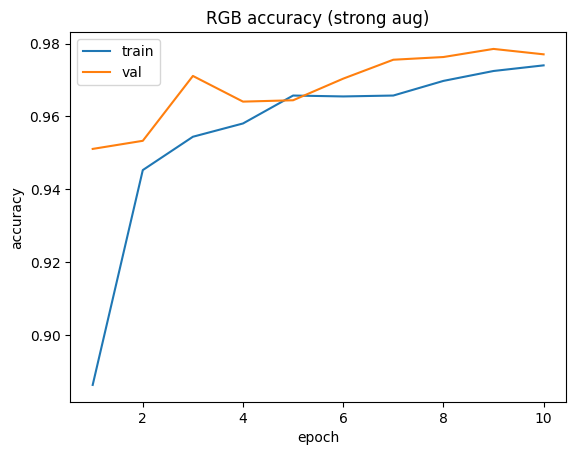

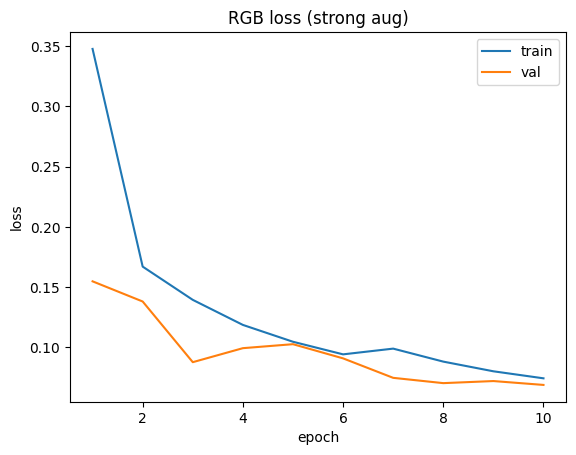

In [2]:
# !pip install --user pandas
# RGB model is stable:
# Figures "RGB accuracy and loss" show the training and validation curves for the RGB model with strong augmentation. 
# Both training and validation accuracy increase steadily and reach values around 97–98% after 10 epochs, while the corresponding losses decrease smoothly. 
# There is no clear divergence between train and validation curves, which indicates that the RGB model does not suffer from severe overfitting in this setting.


import pandas as pd
import matplotlib.pyplot as plt


from config import PROJECT_ROOT

df = pd.read_csv(PROJECT_ROOT / "logs" / "rgb_metrics.csv")


# strong augmentation
df_strong_train = df[(df["aug_name"] == "strong") & (df["split"] == "train")]
df_strong_val   = df[(df["aug_name"] == "strong") & (df["split"] == "val")]

# accuracy
plt.figure()
plt.plot(df_strong_train["epoch"], df_strong_train["accuracy"], label="train")
plt.plot(df_strong_val["epoch"],   df_strong_val["accuracy"],   label="val")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
plt.title("RGB accuracy (strong aug)")
plt.show()

# loss
plt.figure()
plt.plot(df_strong_train["epoch"], df_strong_train["loss"], label="train")
plt.plot(df_strong_val["epoch"],   df_strong_val["loss"],   label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.title("RGB loss (strong aug)")
plt.show()

Loading filename lists...
RGB files: 5400, MS files: 5400
[Hm...OK cat lovers...] RGB and MS filename lists align (same order, same basenames), we continue:

Loading logits...
RGB logits shape: (5400, 10)
MS  logits shape: (5400, 10)

Showing random RGB+MS pairs...

Example idx=1652: HerbaceousVegetation/HerbaceousVegetation_1528.jpg


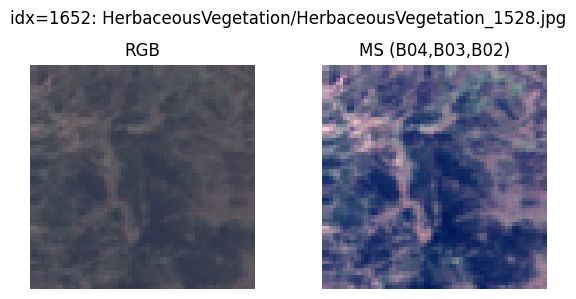


Example idx=1384: HerbaceousVegetation/HerbaceousVegetation_2577.jpg


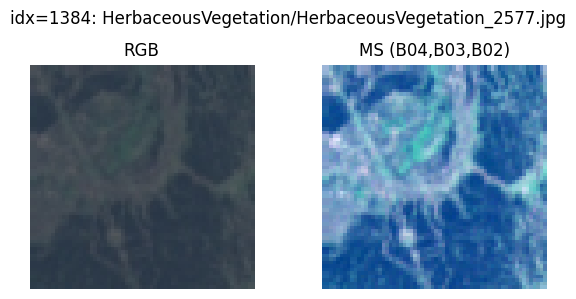


Example idx=523: AnnualCrop/AnnualCrop_890.jpg


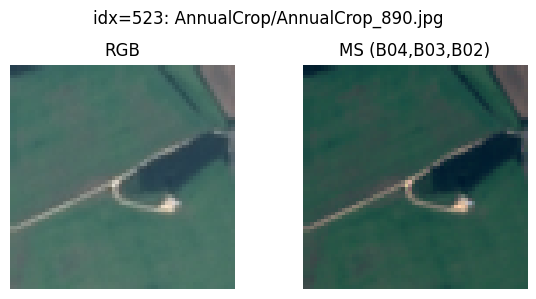


Example idx=2819: Pasture/Pasture_1499.jpg


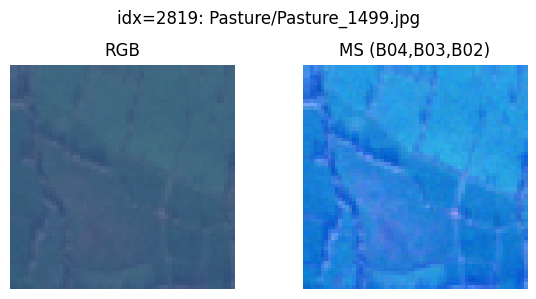


Example idx=5319: SeaLake/SeaLake_1185.jpg


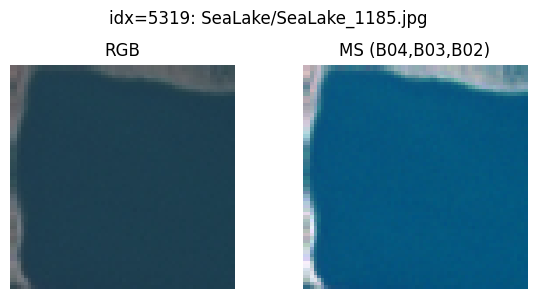


Enter class id (0-9) to inspect top/bottom examples, or 'q' to quit.
  0: AnnualCrop
  1: Forest
  2: HerbaceousVegetation
  3: Highway
  4: Industrial
  5: Pasture
  6: PermanentCrop
  7: Residential
  8: River
  9: SeaLake


Class id (or q):  4



 CLASS 4: Industrial 

RGB TOP-5:
  score=20.0843, file=Industrial/Industrial_675.jpg


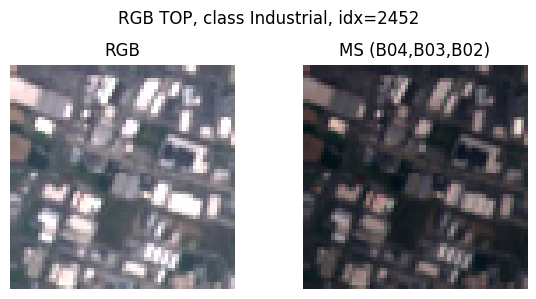

  score=19.8224, file=Industrial/Industrial_663.jpg


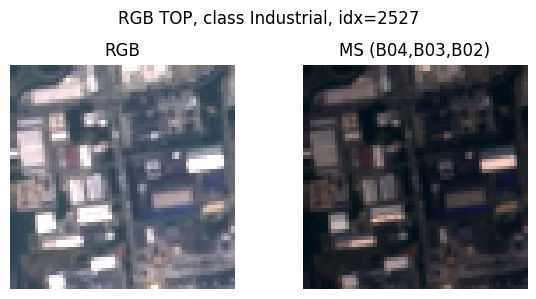

  score=19.4115, file=Industrial/Industrial_232.jpg


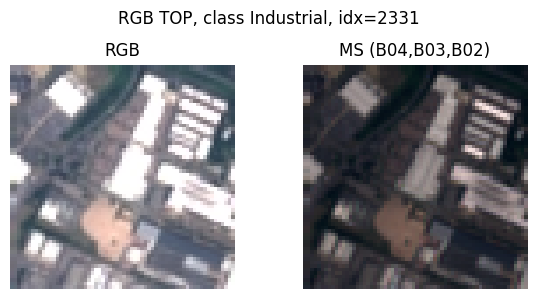

  score=19.1606, file=Industrial/Industrial_230.jpg


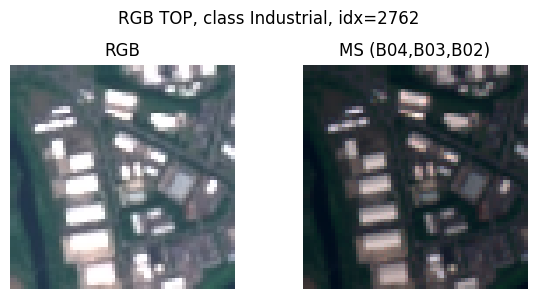

  score=18.9818, file=Industrial/Industrial_4.jpg


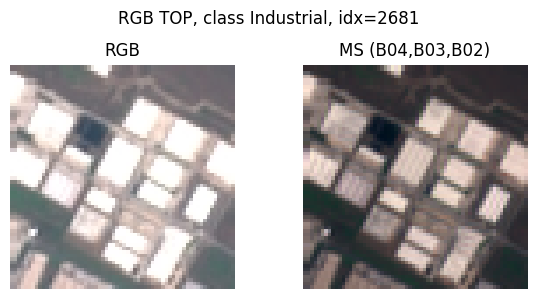


RGB BOTTOM-5:
  score=-6.4003, file=River/River_1995.jpg


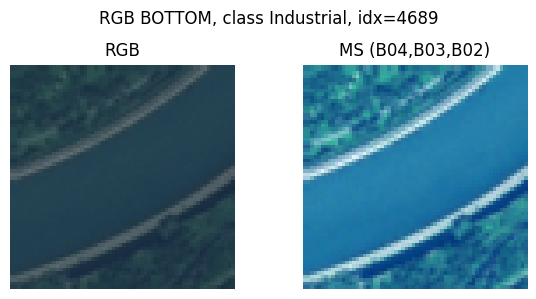

  score=-5.9898, file=River/River_1069.jpg


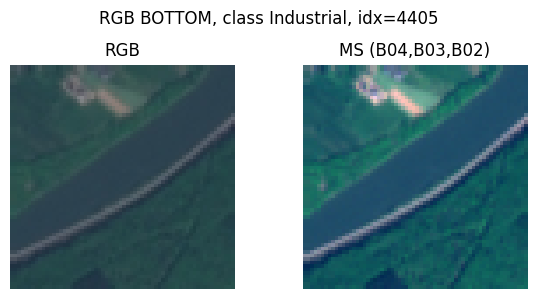

  score=-5.8249, file=River/River_1672.jpg


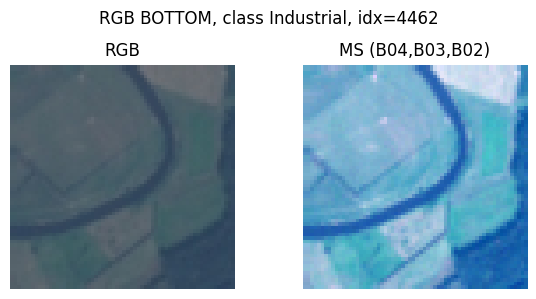

  score=-5.8234, file=River/River_1426.jpg


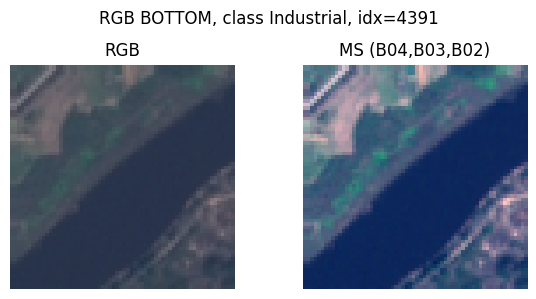

  score=-5.7544, file=River/River_1599.jpg


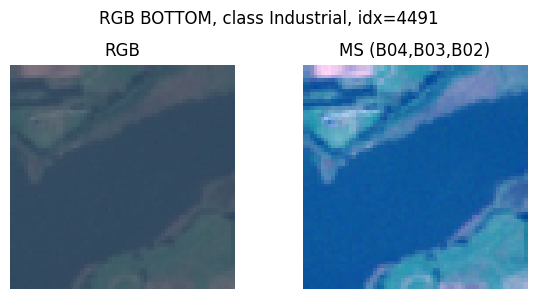


MS TOP-5:
  score=16.1789, file=Industrial/Industrial_1900.tif


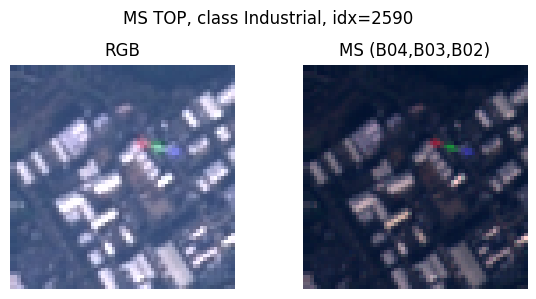

  score=15.5184, file=Industrial/Industrial_2108.tif


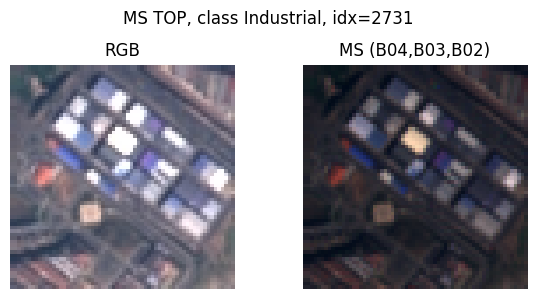

  score=15.1389, file=Industrial/Industrial_1825.tif


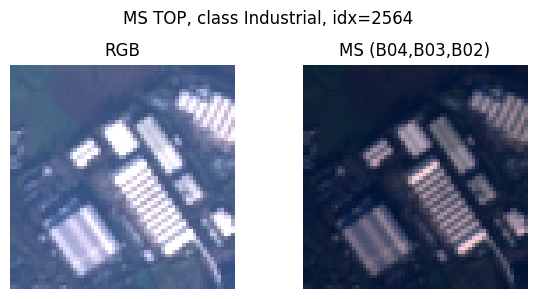

  score=15.1194, file=Industrial/Industrial_974.tif


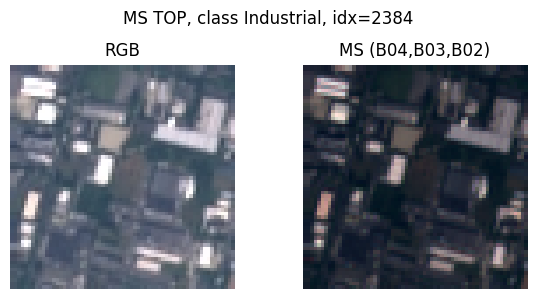

  score=14.6036, file=Industrial/Industrial_445.tif


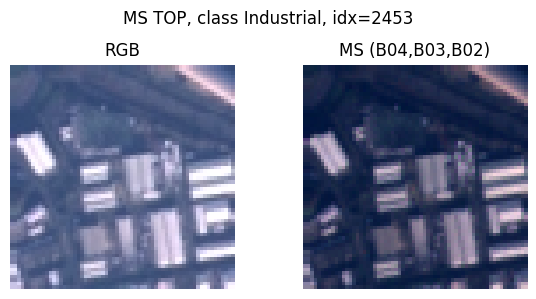


MS BOTTOM-5:
  score=-6.1418, file=Residential/Residential_1658.tif


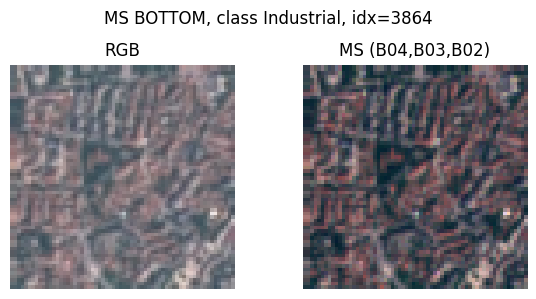

  score=-6.1171, file=River/River_2119.tif


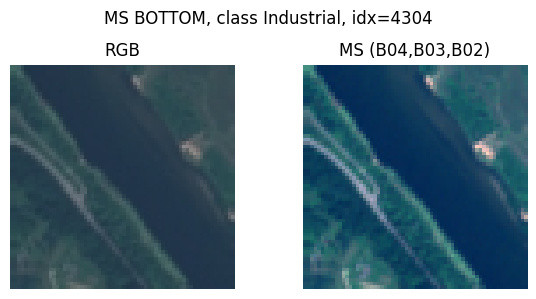

  score=-5.9224, file=Residential/Residential_1560.tif


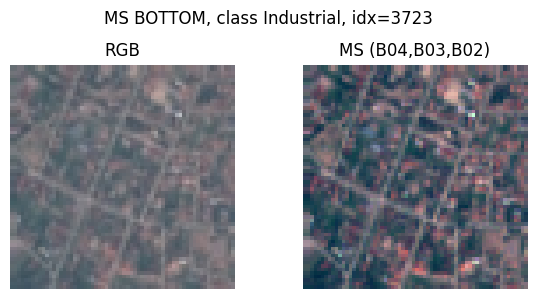

  score=-5.8353, file=HerbaceousVegetation/HerbaceousVegetation_1216.tif


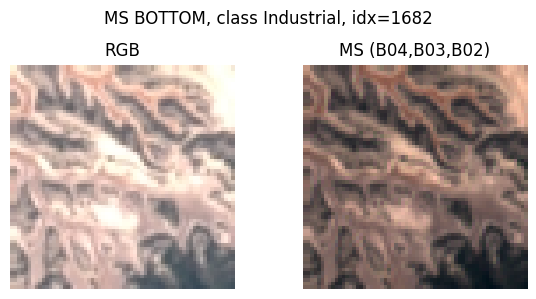

  score=-5.7509, file=River/River_2389.tif


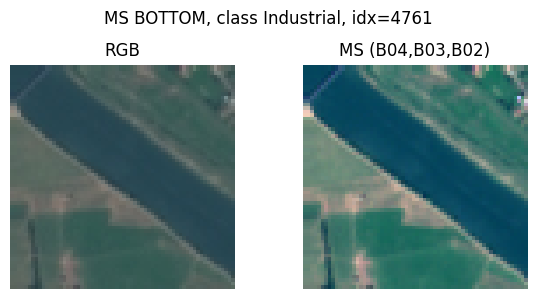


Enter class id (0-9) to inspect top/bottom examples, or 'q' to quit.
  0: AnnualCrop
  1: Forest
  2: HerbaceousVegetation
  3: Highway
  4: Industrial
  5: Pasture
  6: PermanentCrop
  7: Residential
  8: River
  9: SeaLake


Class id (or q):  q


In [6]:
# Visual reprasenation of pictures RGB and MS test set.
#
# top-5 / bottom-5 for each classes logits
#

from pathlib import Path
import random

import numpy as np
import torch
from PIL import Image
from skimage.io import imread
import matplotlib.pyplot as plt
from config import RGB_DATASET_ROOT, MS_DATASET_ROOT, SEED



# ==*==*===*===*====*====*
# CONFIG
# ===*===*===*===*===*===*


RGB_DATASET_ROOT = RGB_DATASET_ROOT
MS_DATASET_ROOT = MS_DATASET_ROOT

RGB_FILENAMES_PATH = PROJECT_ROOT / "predictions" / "rgb_test_filenames.txt"
MS_FILENAMES_PATH = PROJECT_ROOT / "predictions" / "ms_test_filenames.txt"

RGB_LOGITS_PATH = PROJECT_ROOT / "predictions" / "rgb_test_logits.pt"
MS_LOGITS_PATH = PROJECT_ROOT / "predictions" / "ms_test_logits.pt"

# which channels from MS we use (0-based index)
# 0:B01, 1:B02(Blue), 2:B03(Green), 3:B04(Red), ...
MS_RGB_BANDS = (3, 2, 1)  # (Red, Green, Blue)

CLASS_NAMES = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake",
]


def load_filenames(path):
    with path.open("r") as f:
        return [line.strip() for line in f if line.strip()]


def check_alignment(rgb_files, ms_files):
    if len(rgb_files) != len(ms_files):
        print(f"[WARN] Different lengths: RGB={len(rgb_files)}, MS={len(ms_files)}")
        return False

    same_base = True
    for i, (r, m) in enumerate(zip(rgb_files, ms_files)):
        rb = Path(r).with_suffix("").as_posix()
        mb = Path(m).with_suffix("").as_posix()
        if rb != mb:
            print(f"[WARN] mismatch at index {i}:")
            print(f"  RGB: {r}")
            print(f"  MS : {m}")
            same_base = False
            break

    if same_base:
        print(f"[Hm...OK cat lovers...] RGB and MS filename lists align (same order, same basenames), we continue:")
    return same_base


def load_rgb_image(rel_path: str):
    """load RGB image"""
    path = RGB_DATASET_ROOT / rel_path
    img = Image.open(path).convert("RGB")
    return np.array(img)


# changes:
def load_ms_rgb_projection(rel_path: str):
    """load MS .tif and make rgb channel contrasted (B04,B03,B02)
    """
    path = MS_DATASET_ROOT / rel_path
    img = imread(str(path))  

    if img.ndim == 2:
        img = img[:, :, None]

    img = img.astype(np.float32)

    # if (C, H, W), -> (H, W, C)
    if img.shape[0] == 13 and img.shape[-1] != 13:
        # transposing CHW -> HWC
        img = np.transpose(img, (1, 2, 0))

    # normalize to [0,1]
    if img.max() > 1.0:
        img = img / 65535.0

    # 3 channels (Red, Green, Blue) taken
    c_r, c_g, c_b = MS_RGB_BANDS
    if img.shape[2] <= max(MS_RGB_BANDS):
        raise RuntimeError(
            f"MS image {path} has only {img.shape[2]} channels, expected > {max(MS_RGB_BANDS)}"
        )

    rgb_ms = img[:, :, [c_r, c_g, c_b]]  # (H, W, 3)

    # contrast into [0,1], otherwise ms picture shown as black
    mn = rgb_ms.min()
    mx = rgb_ms.max()
    if mx > mn:
        rgb_ms = (rgb_ms - mn) / (mx - mn)
    else:
        rgb_ms = np.zeros_like(rgb_ms)

    rgb_ms = np.clip(rgb_ms, 0.0, 1.0)
    return rgb_ms



def show_pair(rgb_rel, ms_rel, title=None):
    """show RGB + MS configured RGB"""
    rgb_img = load_rgb_image(rgb_rel)
    ms_img = load_ms_rgb_projection(ms_rel)

    plt.figure(figsize=(6, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.axis("off")
    plt.title("RGB")

    plt.subplot(1, 2, 2)
    plt.imshow(ms_img)
    plt.axis("off")
    plt.title("MS (B04,B03,B02)")

    if title is not None:
        plt.suptitle(title)

    plt.tight_layout()
    plt.show()


def random_examples(rgb_files, ms_files, n=5):
    """show random n puctures"""
    idxs = list(range(len(rgb_files)))
    random.Random(RANDOM_SEED).shuffle(idxs)
    idxs = idxs[:n]

    for i in idxs:
        print(f"\nExample idx={i}: {rgb_files[i]}")
        show_pair(rgb_files[i], ms_files[i], title=f"idx={i}: {rgb_files[i]}")


def top_bottom_by_class(
    class_id: int, rgb_files, ms_files, rgb_logits, ms_logits, topk=5
):
    """show top-5 and bottom-5 for given classes with logits"""
    assert 0 <= class_id < rgb_logits.shape[1]

    class_name = CLASS_NAMES[class_id]

    rgb_scores = rgb_logits[:, class_id]
    ms_scores = ms_logits[:, class_id]

    # sort index by its score
    rgb_sorted = np.argsort(rgb_scores)
    ms_sorted = np.argsort(ms_scores)

    rgb_top = rgb_sorted[-topk:]
    rgb_bottom = rgb_sorted[:topk]

    ms_top = ms_sorted[-topk:]
    ms_bottom = ms_sorted[:topk]

    print(f"\n CLASS {class_id}: {class_name} ")

    # RGB TOP
    print("\nRGB TOP-5:")
    for idx in reversed(rgb_top):
        print(f"  score={rgb_scores[idx]:.4f}, file={rgb_files[idx]}")
        show_pair(rgb_files[idx], ms_files[idx], title=f"RGB TOP, class {class_name}, idx={idx}")

    # RGB BOTTOM
    print("\nRGB BOTTOM-5:")
    for idx in rgb_bottom:
        print(f"  score={rgb_scores[idx]:.4f}, file={rgb_files[idx]}")
        show_pair(rgb_files[idx], ms_files[idx], title=f"RGB BOTTOM, class {class_name}, idx={idx}")

    # MS TOP
    print("\nMS TOP-5:")
    for idx in reversed(ms_top):
        print(f"  score={ms_scores[idx]:.4f}, file={ms_files[idx]}")
        show_pair(rgb_files[idx], ms_files[idx], title=f"MS TOP, class {class_name}, idx={idx}")

    # MS BOTTOM
    print("\nMS BOTTOM-5:")
    for idx in ms_bottom:
        print(f"  score={ms_scores[idx]:.4f}, file={ms_files[idx]}")
        show_pair(rgb_files[idx], ms_files[idx], title=f"MS BOTTOM, class {class_name}, idx={idx}")


def main():
    print("Loading filename lists...")
    rgb_files = load_filenames(RGB_FILENAMES_PATH)
    ms_files = load_filenames(MS_FILENAMES_PATH)
    print(f"RGB files: {len(rgb_files)}, MS files: {len(ms_files)}")

    aligned = check_alignment(rgb_files, ms_files)
    if not aligned:
        print("WARNING: lists are not aligned; continue at your own risk :)")

    print("\nLoading logits...")
    rgb_logits = torch.load(RGB_LOGITS_PATH, map_location="cpu").numpy()  # (N, C)
    ms_logits = torch.load(MS_LOGITS_PATH, map_location="cpu").numpy()

    print(f"RGB logits shape: {rgb_logits.shape}")
    print(f"MS  logits shape: {ms_logits.shape}")

    # random samples
    print("\nShowing random RGB+MS pairs...")
    random_examples(rgb_files, ms_files, n=5)

    # top/bottom for selected class
    while True:
        print("\nEnter class id (0-9) to inspect top/bottom examples, or 'q' to quit.")
        for i, name in enumerate(CLASS_NAMES):
            print(f"  {i}: {name}")
        s = input("Class id (or q): ").strip()
        if s.lower() == "q":
            break
        try:
            cid = int(s)
        except ValueError:
            print("Not a valid integer, try again.")
            continue
        if 0 <= cid < len(CLASS_NAMES):
            top_bottom_by_class(cid, rgb_files, ms_files, rgb_logits, ms_logits)
        else:
            print("Class id out of range, try again.")


if __name__ == "__main__":
    main()
